# ANÁLISE DA BASE DE DADOS ORIGINAL 

#### Neste notebook são apresentadas informações gerais sobre a base de dados (`Complete_Pokedex_V1.1.csv`) com o objetivo de compreender a base em sua forma original, ou seja, sem tratamentos e registrar as suas características e realizar as análises visuais iniciais.

## Configuração Inicial

### Importação de Bibliotecas

Importação das bibliotecas que serão usadas: `pandas` para manipulação dos dados, `matplotlib.pyplot` e `seaborn` para a geração dos gráficos.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Extração dos Dados

Carregar o dataset `Complete_Pokedex_V1.1.csv` da camada `raw` para um DataFrame.

In [32]:
dataFrame = pd.read_csv("Complete_Pokedex_V1.1.csv")

## Diagnóstico e Análise Descritiva

### Visualização das Colunas

Exibir a lista completa de colunas disponíveis no dataset.

In [33]:
print("Colunas disponíveis:")
print(dataFrame.columns.tolist())

Colunas disponíveis:
['pokedex_number', 'pokemon_name', 'type_1', 'type_2', 'ability_1', 'ability_2', 'ability_3', 'number_pokemon_with_typing', 'primary_color', 'shape', 'height', 'weight', 'bmi', 'hit_points', 'attack', 'defense', 'special_attack', 'special_defense', 'speed', 'total_stats', 'mean', 'standard_deviation', 'capture_rate', 'generation', 'base_happiness', 'base_experience', 'exp_type', 'exp_to_level_100', 'can_evolve', 'evolves_from', 'final_evolution', 'mega_evolution', 'is_default', 'baby_pokemon', 'alolan_form', 'galarian_form', 'forms_switchable', 'legendary', 'mythical', 'genderless', 'female_rate', 'genus', 'egg_group_1', 'egg_group_2', 'egg_cycles', 'against_normal', 'against_fire', 'against_water', 'against_electric', 'against_grass', 'against_ice', 'against_fighting', 'against_poison', 'against_ground', 'against_flying', 'against_psychic', 'against_bug', 'against_rock', 'against_ghost', 'against_dragon', 'against_dark', 'against_steel', 'against_fairy']


### Amostra dos Dados

Visualizar as 5 primeiras linhas para uma verificação rápida da estrutura e dos dados.

In [34]:
print("---------------------------------------")
print("Total de linhas da base de dados:", len(dataFrame))
print("---------------------------------------")
print("Total de colunas:", len(dataFrame.columns)) 
print("---------------------------------------")

---------------------------------------
Total de linhas da base de dados: 1118
---------------------------------------
Total de colunas: 63
---------------------------------------


## Análises Gráficas

### Gráfico de Regressão: Ataque vs. Defesa

Este gráfico de regressão mostra a relação entre os atributos de Ataque e Defesa dos Pokémon. 

Text(0.05, 0.95, 'Correlação: 0.461')

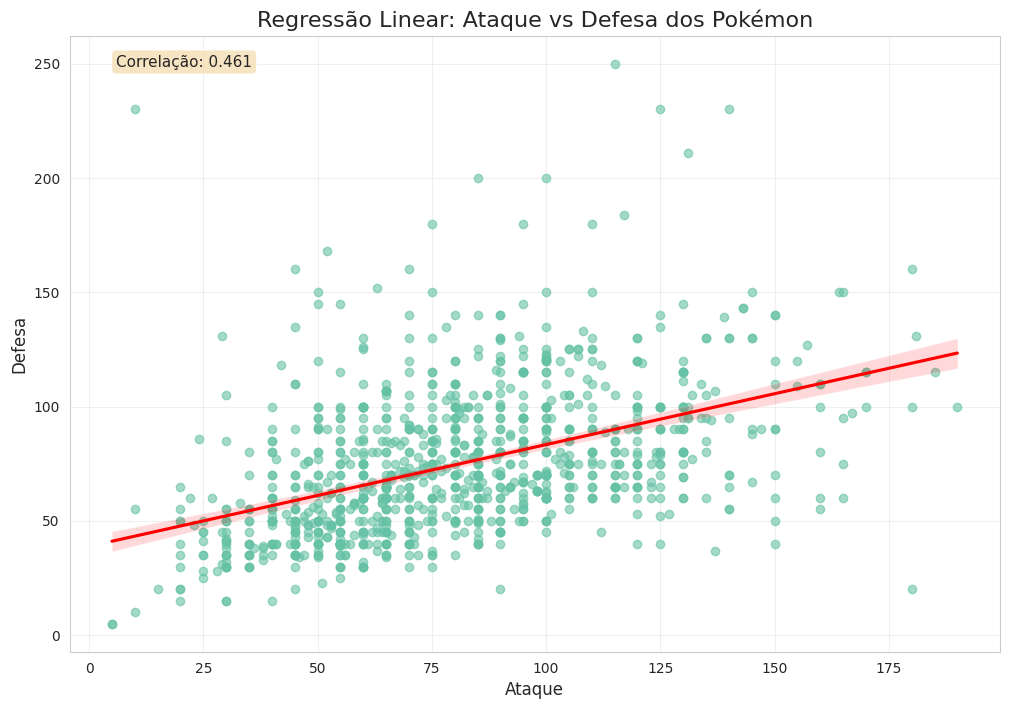

In [35]:
plt.figure(figsize=(12, 8))

# Criar o gráfico de regressão
sns.regplot(data=dataFrame, x='attack', y='defense', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

# Adicionar títulos e formatação
plt.title('Regressão Linear: Ataque vs Defesa dos Pokémon', fontsize=16)
plt.xlabel('Ataque', fontsize=12)
plt.ylabel('Defesa', fontsize=12)
plt.grid(True, alpha=0.3)

# Calcular e exibir a correlação
correlation = dataFrame['attack'].corr(dataFrame['defense'])
plt.text(0.05, 0.95, f'Correlação: {correlation:.3f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8), fontsize=11)


**Explicação do gráfico de regressão de Ataque vs Defesa:**

Este gráfico de regressão mostra a relação entre os atributos de Ataque e Defesa dos Pokémon. A linha vermelha representa a tendência linear entre essas duas variáveis. O coeficiente de correlação indica o grau de associação entre elas, onde valores próximos a 1 indicam correlação positiva forte, próximos a -1 indicam correlação negativa forte, e próximos a 0 indicam pouca ou nenhuma correlação linear.

### Gráfico de Regressão: HP vs. Total de Stats

Text(0.05, 0.95, 'Correlação: 0.492')

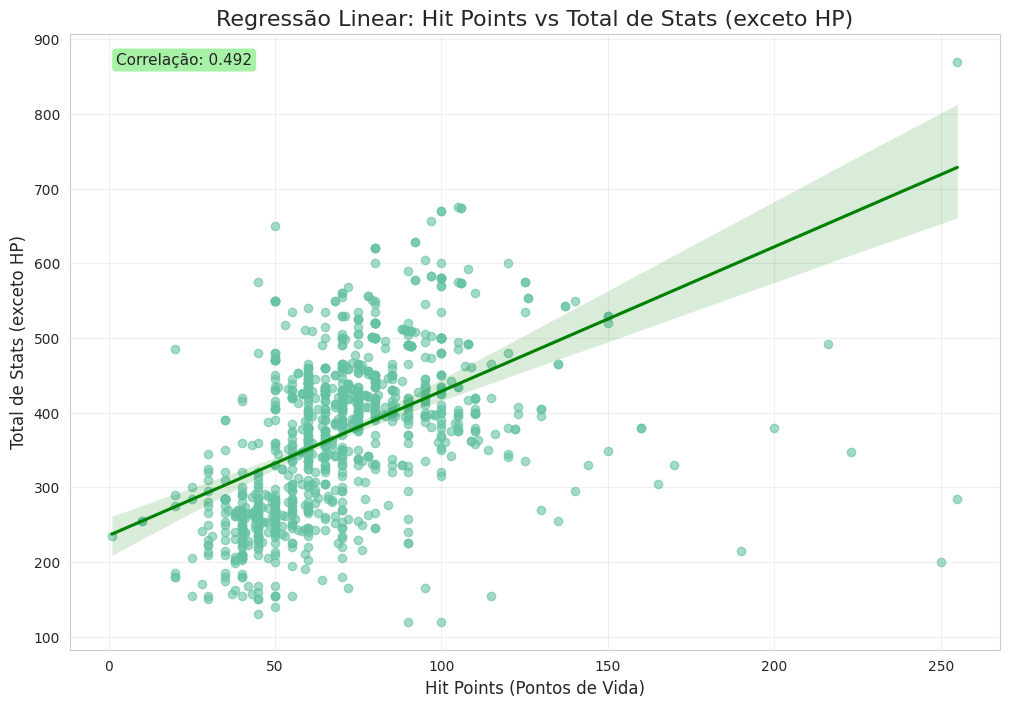

In [36]:
plt.figure(figsize=(12, 8))

# Criar a coluna temporária para a análise
dataFrame['total_stats_except_hp'] = (dataFrame['attack'] + dataFrame['defense'] + 
                                    dataFrame['special_attack'] + dataFrame['special_defense'] + 
                                    dataFrame['speed'])

# Criar o gráfico de regressão
sns.regplot(data=dataFrame, x='hit_points', y='total_stats_except_hp', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'green'})

# Adicionar títulos e formatação
plt.title('Regressão Linear: Hit Points vs Total de Stats (exceto HP)', fontsize=16)
plt.xlabel('Hit Points (Pontos de Vida)', fontsize=12)
plt.ylabel('Total de Stats (exceto HP)', fontsize=12)
plt.grid(True, alpha=0.3)

# Calcular e exibir a correlação
correlation2 = dataFrame['hit_points'].corr(dataFrame['total_stats_except_hp'])
plt.text(0.05, 0.95, f'Correlação: {correlation2:.3f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle="round", facecolor='lightgreen', alpha=0.8), fontsize=11)

**Explicação do gráfico de regressão de Hit Points vs Total de Stats:**

Este gráfico analisa se Pokémon com maior Hit Points (pontos de vida) tendem a ter stats totais mais altos (excluindo os próprios Hit Points para evitar redundância). A linha verde mostra a tendência, e a correlação nos ajuda a entender se existe um padrão de balanceamento no design dos Pokémon - se criaturas com mais pontos de vida também tendem a ser mais poderosas em outros aspectos.

### Gráfico de Pizza

In [37]:
# Configurar o estilo e paleta do Seaborn
sns.set_style("whitegrid")
sns.set_palette("Set2")

# Define o Pokémon que será analisado
pokemon_name = "Pikachu"

In [38]:
# Encontrar o Pokémon 
pokemon_data = dataFrame[dataFrame.iloc[:, 1].str.lower() == pokemon_name.lower()]

# Obter a primeira linha de dados e o nome
pokemon = pokemon_data.iloc[0]
name = pokemon.iloc[1]  # Pokémon name

In [39]:
# Coletar os status das colunas corretas por sua posição (índice)
attack = pokemon.iloc[14]   # Posição 14: attack
defense = pokemon.iloc[15]  # Posição 15: defense
speed = pokemon.iloc[18]    # Posição 18: speed

# Preparar os dados para o gráfico
stats = [attack, defense, speed]
labels = ['Ataque', 'Defesa', 'Velocidade']

In [40]:
# Imprime os status base antes de plotar
print(f"⚡ {name} Stats:")
print(f"   Ataque: {attack}")
print(f"   Defesa: {defense}")
print(f"   Velocidade: {speed}")
print(f"   Total (parcial): {sum(stats)}")

⚡ Pikachu Stats:
   Ataque: 55
   Defesa: 40
   Velocidade: 90
   Total (parcial): 185


In [41]:
# Criar a figura do gráfico
plt.figure(figsize=(10, 8))

# Definir a paleta de cores
colors = sns.color_palette("Set2", 3)

<Figure size 1000x800 with 0 Axes>

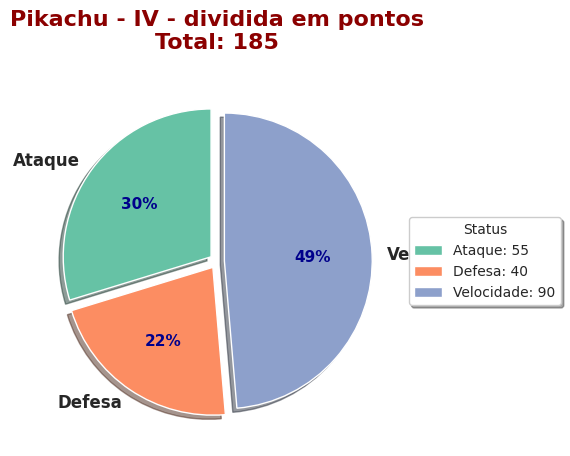

In [42]:
# Plota o gráfico de pizza com sombra e fatias separadas
wedges, texts, autotexts = plt.pie(
    stats,
    labels=labels,
    colors=colors,
    autopct='%1.0f%%',
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Altera a cor e fonte do texto 'autopct'
for autotext in autotexts:
    autotext.set_color('darkblue')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Adiciona o título com o total de status
total_stats_pie = sum(stats)
plt.title(f"{name} - IV - dividida em pontos\nTotal: {total_stats_pie}", 
          fontsize=16, fontweight='bold', pad=20, color='darkred')

# Cria rótulos personalizados para a legenda
legend_labels = [f"{label}: {value}" for label, value in zip(labels, stats)]

# Plota a legenda fora do gráfico para não sobrepor
plt.legend(wedges, legend_labels,
          title="Status",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          frameon=True,
          fancybox=True,
          shadow=True)

Este gráfico de pizza detalha o perfil de combate de um Pokémon individual, exemplificado com o Pikachu. As fatias mostram a distribuição percentual dos seus status de **Ataque**, **Defesa** e **Velocidade**, em relação ao total combinado desses três atributos (185 pontos).

**O funcionamento do gráfico é:**
* **Seleção:** A função permite que qualquer Pokémon do dataset seja analisado individualmente.
* **Fatias:** Cada fatia colorida representa um dos três status selecionados (`Ataque`, `Defesa`, `Velocidade`).
* **Porcentagem:** O valor em cada fatia indica a proporção daquele status. No caso do Pikachu, é visível que sua principal característica é a **Velocidade** (quase metade do total), enquanto sua **Defesa** é seu ponto mais frágil. A legenda à direita complementa com os valores absolutos de cada atributo.

### Gráfico de Boxplot

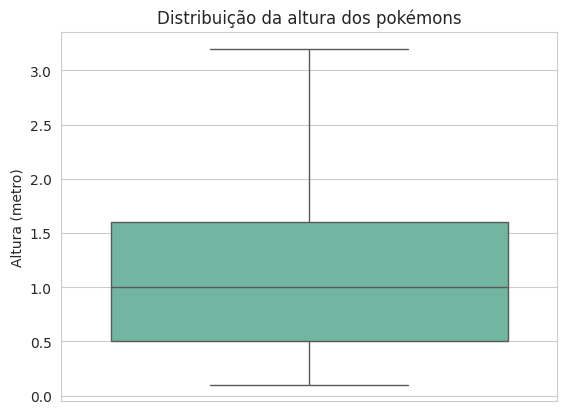

In [43]:
sns.boxplot(y=dataFrame["height"], showfliers=False) # showfliers=False esconde os outliers do gráfico

plt.title("Distribuição da altura dos pokémons")
plt.ylabel("Altura (metro)")
plt.show()

Esse gráfico de Boxplot demonstra que a maioria dos Pokémon tem altura entre 0,5 e 1,5 m, com maior variação para alturas mais altas.

A linha horizontal dentro da caixa azul indica a mediana que é de aproximadamente 1 metro, dividindo o conjunto em duas metades.
A caixa Azul representa os quartis:
o primeiro quartil (Q1): em torno de 0,5 m, mostra que 25% dos Pokémon têm altura menor que este valor
o primeiro quartil (Q2): é a mediana, que é de aproximadamente 1 metro, dividindo o conjunto em duas metades.
terceiro quartil (Q3): cerca de 1,5 m, indica que 75% têm altura menor que este valor.
Os bigodes: se estendem da caixa até os valores mínimo (+-0,1 m) e máximo (+-3,2 m) dentro do intervalo considerado normal, mostrando a dispersão dos dados.
Os outliers foram ocultados com o comando showfliers=False, ou seja, Pokémon com alturas extremamente baixas ou altas não aparecem no gráfico, mas ainda existem nos dados originais.

### Gráfico de Regressão

Text(0, 0.5, 'Defesa especial')

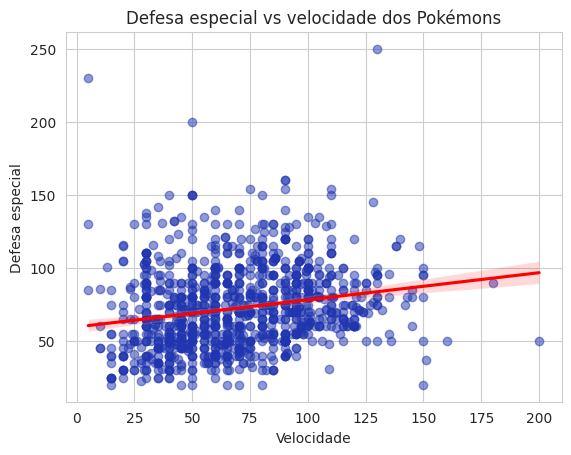

In [44]:
sns.regplot( 
    y=dataFrame["special_defense"], 
    x=dataFrame["speed"], 
    scatter_kws={"alpha": 0.5, "color": "#2035AF"}, 
    line_kws={"color": "red"} 
) 

plt.title("Defesa especial vs velocidade dos Pokémons") 
plt.xlabel("Velocidade") 
plt.ylabel("Defesa especial") 

No gráfico, a linha vermelha mostra a tendência geral entre Defesa especial e velocidade.
A tendência (relação) entre a velocidade e defesa é considerada fraca porque os pontos azuis estão muito espalhados em torno da linha, sem formar um agrupamento próximo.
A linha vermelha indica que, em média, Pokémons mais rápidos tendem a ter defesa especial um pouco maior, pois a inclinação da linha mostra esse crescimento gradual: quando a velocidade aumenta no eixo horizontal, a linha também sobe no eixo vertical, refletindo esse padrão médio.

### Gráfico de Histograma

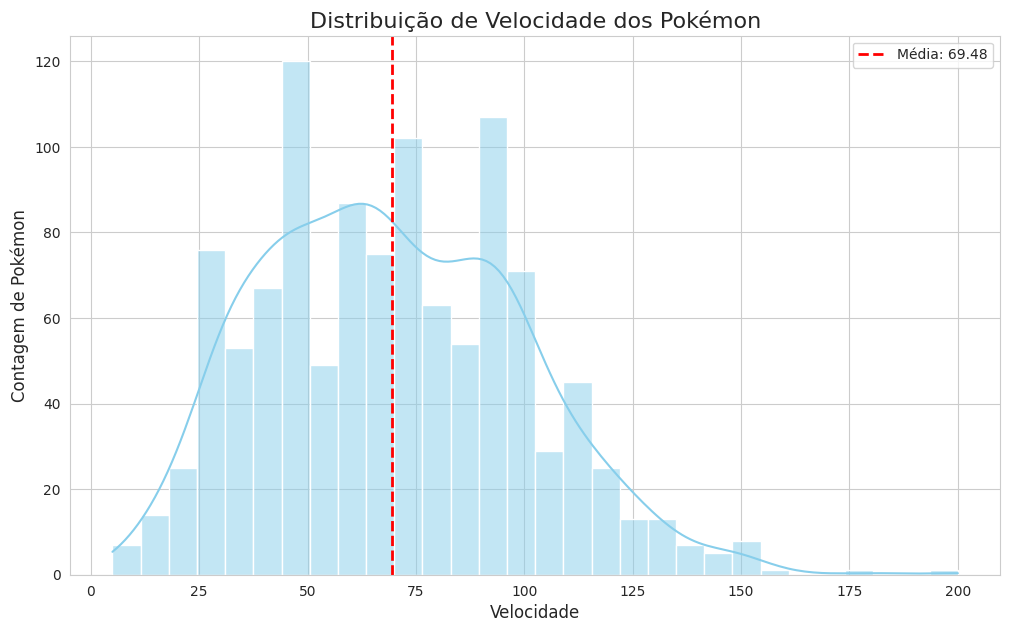

In [45]:
plt.figure(figsize=(12, 7))

# Calcula a velocidade média como referência
mean_speed = dataFrame['speed'].mean()

sns.histplot(data=dataFrame, x='speed', kde=True, bins=30, color='skyblue')

# Adiciona uma linha vertical
plt.axvline(mean_speed, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_speed:.2f}')

plt.title("Distribuição de Velocidade dos Pokémon", fontsize=16)
plt.xlabel("Velocidade", fontsize=12)
plt.ylabel("Contagem de Pokémon", fontsize=12)
plt.legend()


**Explicação do gráfico:** Este histograma mostra, de forma bem direta, a distribuição do atributo de Velocidade (speed), revelando como os Pokémon se concentram em diferentes faixas de agilidade. Dessa maneira, o que chama a atenção é a grande concentração de Pokémon com velocidade moderada, situados principalmente entre 40 e 100 pontos, com um pico próximo da média de 76.56. Em contraste, a curva mostra uma "cauda" para a direita a qual indica um grupo de elite de Pokémon mais rápidos.

**O funcionamento do gráfico:**

* O eixo horizontal (X) representa as faixas do atributo Velocidade.
* O eixo vertical (Y) mostra a contagem de quantos Pokémon existem em cada faixa.
* A linha azul (curva de densidade) suaviza as barras para mostrar a tendência geral da distribuição, enquanto a linha vermelha marca o ponto de velocidade média de todo o conjunto de dados.

### Gráficos de Barras

**Quantidade de Pokémon por Geração**

Text(0, 0.5, 'Quantidade de Pokémon - Unidade')

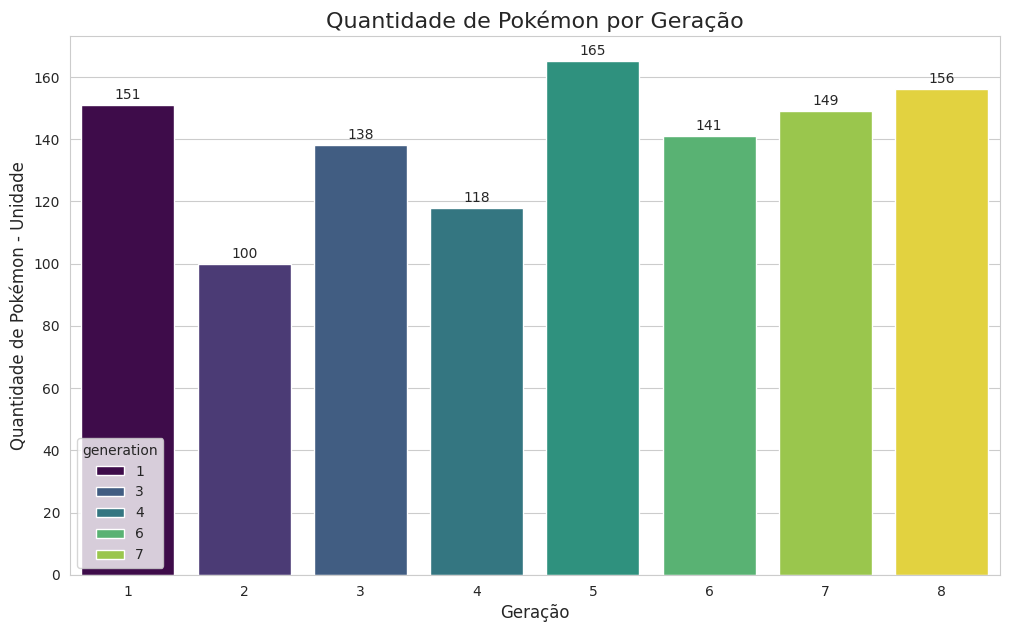

In [46]:
# Conta a quantidade de Pokémon
gen_counts = dataFrame['generation'].value_counts().sort_index()

plt.figure(figsize=(12, 7))

# O parâmetro 'hue' garante que cada barra tenha uma cor diferente
sns.barplot(x=gen_counts.index, y=gen_counts.values, palette='viridis', hue=gen_counts.index, dodge=False)

for index, value in enumerate(gen_counts):
    plt.text(index, value + 1, str(value), ha='center', va='bottom', fontsize=10)

plt.title("Quantidade de Pokémon por Geração", fontsize=16)
plt.xlabel("Geração", fontsize=12)
plt.ylabel("Quantidade de Pokémon - Unidade", fontsize=12)


Este gráfico de barras mostra, de forma bem direta, como a franquia Pokémon expandiu seu conteúdo ao longo das oito gerações, ou seja, representa quantos deles foram adicionados em cada uma das edições. Dessa forma, por exemplo, o que chama bastante atenção são os picos das gerações 1, no final dos anos 90, e da geração 5, entre 2010 e 2013. Em contraste, a Geração 6 (2013-2016) foi a que menos adicionou novas criaturas, época em que houve uma mudança de foco da quantidade de Pokémon para a introdução de novas Mega Evoluções.

**O funcionamento do gráfico:**

* O eixo horizontal (X) categoriza cada uma das 8 gerações.
* O eixo vertical (Y) mede a contagem total de Pokémon por geração.

**Tipos de Pokémon**

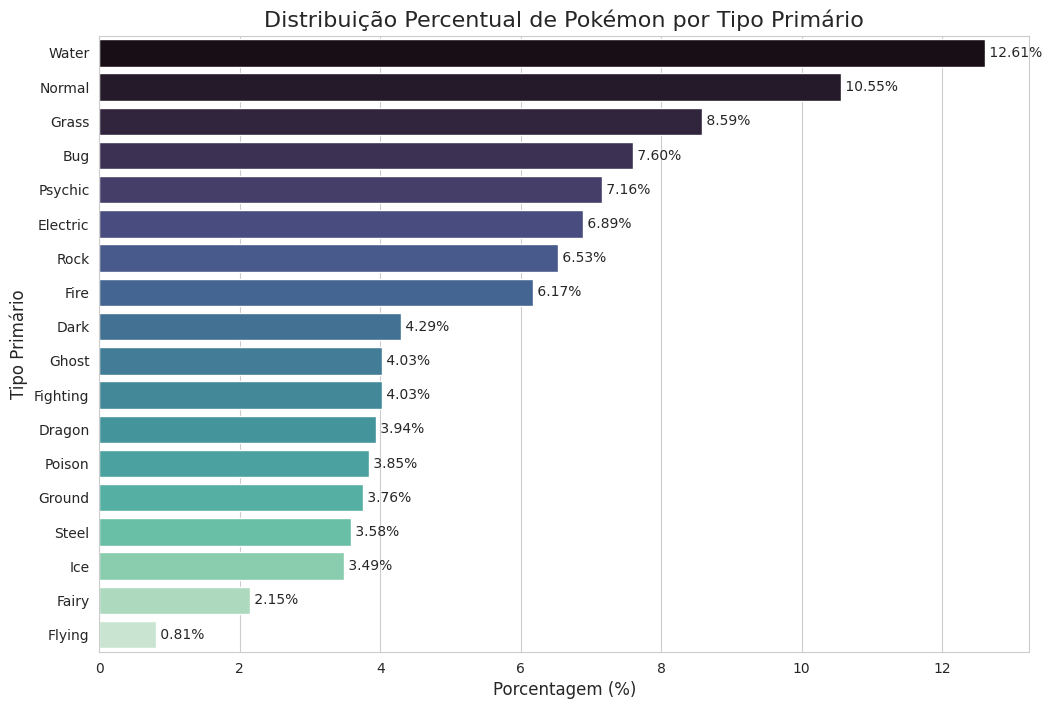

In [47]:
# Contar a frequência de cada tipo na coluna 'type_1'
type_counts = dataFrame['type_1'].value_counts()

total_pokemon = len(dataFrame)
type_percentages = (type_counts / total_pokemon) * 100

plt.figure(figsize=(12, 8))

sns.barplot(x=type_percentages.values, y=type_percentages.index, palette='mako', hue=type_percentages.index, dodge=False)

plt.title("Distribuição Percentual de Pokémon por Tipo Primário", fontsize=16)
plt.xlabel("Porcentagem (%)", fontsize=12)
plt.ylabel("Tipo Primário", fontsize=12)

for index, value in enumerate(type_percentages):
    plt.text(value, index, f' {value:.2f}%', va='center')



Este gráfico de barras horizontais mostra algo que parece só uma curiosidade, mas na real é uma regra de design super importante dentro do universo Pokémon: a forma como os tipos elementares são distribuídos. Dessa forma, é observado a predominância do tipo Água (Water), que representa mais de 11% de todas as criaturas, seguido pelos tipos Normal e Grama (Grass), o que consolida os elementos básicos como os mais comuns. Em contraste, é observado também que o tipo Voador (Flying) aparece como o menos frequente entre os tipos primários.

**O funcionamento do gráfico é:**

* O eixo vertical (Y) categoriza cada um dos 18 tipos primários, ordenando-os do mais ao menos comum.
* O eixo horizontal (X) mede a participação percentual de cada tipo no total de Pokémon.

### Análise Avançada: Matrizes de Correlação

#### Matriz de Correlação dos Atributos de Batalha

Primeiro, uma análise de correlação entre os atributos numéricos de batalha. Este gráfico (`heatmap`) mostra quais atributos tendem a crescer juntos. Células com valores próximos de 1.0 (vermelho escuro) indicam uma correlação positiva forte.

# Seleciona apenas as colunas de stats que serão comparadas
colunas_stats = ['hit_points', 'attack', 'defense', 'special_attack', 'special_defense', 'speed', 'total_stats']

In [48]:
# Seleciona apenas as colunas de stats que serão comparadas
colunas_stats = ['hit_points', 'attack', 'defense', 'special_attack', 'special_defense', 'speed', 'total_stats']

In [49]:
# Cria um DataFrame temporário apenas com esses status
df_stats = dataFrame[colunas_stats]

In [50]:
# Calcula a correlação entre eles
correlacao = df_stats.corr()

In [51]:
# Configura o tamanho da figura
plt.figure(figsize=(10, 7))

<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

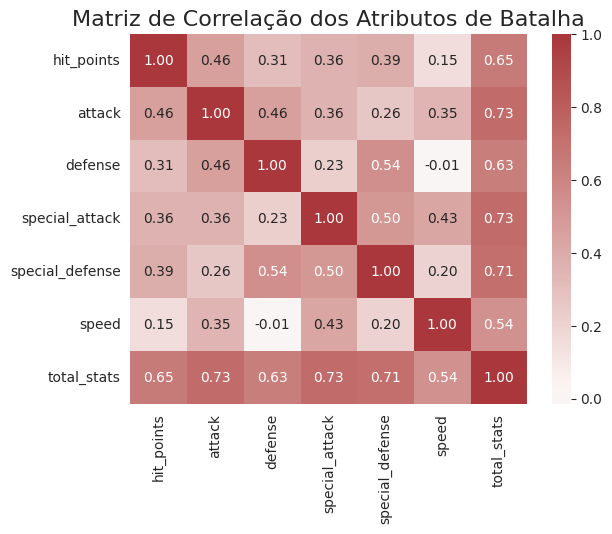

In [52]:
# Desenha o gráfico (heatmap)
sns.heatmap(correlacao, annot=True, cmap='vlag', fmt='.2f', center=0)
plt.title('Matriz de Correlação dos Atributos de Batalha', fontsize=16)
plt.show()

#### Análise de Eficiência de Tipo

Um dos fatores mais importantes em um combate é a questão de fraquezas e resistências. Para analisar a eficiência de um tipo atacante contra um defensor, usa-se a fórmula:

> **Eficiência = Multiplicador de Ataque / Multiplicador de Defesa**

Um Pokémon **Planta** contra um tipo **Água**:
* Eficiência = 2 (Ataque super efetivo) / 0.5 (Resistência ao dano) = **4**

Um Pokémon **Elétrico** contra um tipo **Água**:
* Eficiência = 2 (Ataque super efetivo) / 1.0 (Dano neutro) = **2**

Portanto, o tipo Planta é duas vezes mais eficiente. A matriz a seguir analisa a relação de fraqueza e resistência apenas para os **Tipos Puros**.

####  Preparação dos Dados

Para criar a matriz de tipos puros, é feito um **filtro** no DataFrame original para selecionar apenas os Pokémon que **não possuem `type_2`** (ou seja, `type_2` é Nulo/NaN).

Isto **não é um tratamento**, é uma **análise de um subconjunto** dos dados brutos.

In [53]:
# Filtro que transforma lista de 150+ combinações de tipos em uma lista de apenas 18 tipos puros.
df_tipos_puros = dataFrame[dataFrame['type_2'].isnull()].copy() 

df_tipos_puros = df_tipos_puros.drop_duplicates(subset=['type_1'])

df_tipos_puros = df_tipos_puros.set_index('type_1')

# Seleciona apenas as colunas 'against_'
colunas_against = [col for col in dataFrame.columns if col.startswith('against_')]
df_tipos_puros_heatmap = df_tipos_puros[colunas_against]


#### Matriz de Fraquezas (Tipos Puros)

Este heatmap 18x18 é legível e mostra a "pedra-papel-tesoura" fundamental do jogo. Células vermelhas indicam fraqueza (dano > 1) e células azuis indicam resistência (dano < 1).

In [54]:
# Define um bom tamanho para a matriz 18x18
plt.figure(figsize=(20, 12))

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Axes: ylabel='type_1'>

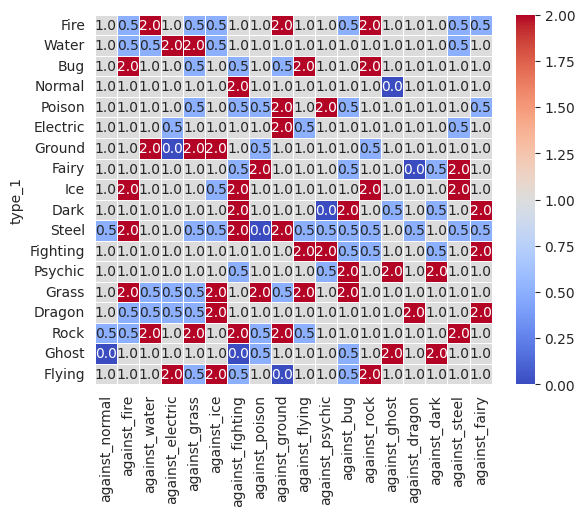

In [55]:
# Cria o heatmap
sns.heatmap(
    df_tipos_puros_heatmap, 
    annot=True,     # Mostra os números (multiplicadores)
    cmap='coolwarm',# Mapa de cores: Frio (azul) para < 1, Quente (vermelho) para > 1
    center=1.0,     # Centraliza a cor neutra (dano 1x) no branco
    linewidths=.5,  # Adiciona linhas finas entre as células
    fmt='.1f'       # Formata os números para 1 casa decimal
)